In [1]:
#!pip install arxiv

import arxiv
import pandas as pd

# --- CONFIGURACIÓN ---
query = "quantum machine learning"  # cambia por tu tema
max_papers = 1000                    # número de abstracts que quieres

# --- BÚSQUEDA ---
search = arxiv.Search(
    query=query,
    max_results=max_papers,
    sort_by=arxiv.SortCriterion.SubmittedDate
)

# --- scrapear RESULTADOS ---
data = []
for paper in search.results():
    data.append({
        "title": paper.title,
        "authors": [a.name for a in paper.authors],
        "abstract": paper.summary,
        "arxiv_id": paper.get_short_id(),
        "category": paper.primary_category,
        "date": paper.published,
        "pdf_url": paper.pdf_url
    })

df = pd.DataFrame(data)

# --- GUARDAR EN CSV ---
df.to_csv("arxiv_abstracts.csv", index=False)

df.head()


C:\Users\laura\AppData\Local\Temp\ipykernel_26040\1085921158.py:19: DeprecationWarning: The 'Search.results' method is deprecated, use 'Client.results' instead
  for paper in search.results():


,title,authors,abstract,arxiv_id,category,date,pdf_url
0,On the treatment of thermal effects in the equ...,"[Davide Guerra, Milton Ruiz, Michele Pasquali,...","We present results from long-term, numerical-r...",2512.05118v1,gr-qc,2025-12-04 18:59:58+00:00,https://arxiv.org/pdf/2512.05118v1
1,The Universal Weight Subspace Hypothesis,"[Prakhar Kaushik, Shravan Chaudhari, Ankit Vai...",We show that deep neural networks trained acro...,2512.05117v1,cs.LG,2025-12-04 18:59:58+00:00,https://arxiv.org/pdf/2512.05117v1
2,Value Gradient Guidance for Flow Matching Alig...,"[Zhen Liu, Tim Z. Xiao, Carles Domingo-Enrich,...",While methods exist for aligning flow matching...,2512.05116v1,cs.LG,2025-12-04 18:59:57+00:00,https://arxiv.org/pdf/2512.05116v1
3,Deep infant brain segmentation from multi-cont...,"[Malte Hoffmann, Lilla Zöllei, Adrian V. Dalca]",Segmentation of magnetic resonance images (MRI...,2512.05114v1,cs.LG,2025-12-04 18:59:55+00:00,https://arxiv.org/pdf/2512.05114v1
4,DraCo: Draft as CoT for Text-to-Image Preview ...,"[Dongzhi Jiang, Renrui Zhang, Haodong Li, Zhuo...",Recent unified multimodal large language model...,2512.05112v1,cs.CV,2025-12-04 18:59:53+00:00,https://arxiv.org/pdf/2512.05112v1


# Cómo construir una ecuación de búsqueda para arXiv

Una **ecuación de búsqueda en arXiv** es una cadena de texto que combina palabras clave con operadores lógicos para localizar papers relevantes de manera precisa.

## 1. Operadores booleanos

### **`AND`**
El documento debe contener *ambos* términos.
quantum AND "partial differential equation"

### **`OR`**
El documento puede contener uno u otro término.
PDE OR "differential equations"

### **`AND NOT`**
Incluye un término y excluye otro.
quantum AND NOT chemistry

## 2. Búsquedas exactas con comillas
Usa comillas para buscar frases completas:
"quantum neural network"

Sin comillas se busca cada palabra por separado.

## 3. Agrupar ideas con paréntesis

Sirve para combinar varios conceptos:
("quantum neural network" OR "quantum machine learning")
AND
("partial differential equation" OR PDE)

## 4. Buscar en categorías específicas de arXiv

ArXiv clasifica los papers por áreas. Para buscar solo dentro de una categoría:

cat:quant-ph
cat:cs.LG
cat:math.AP

Ejemplo:
("quantum neural" AND PDE) AND cat:quant-ph

## 5. Buscar por autor
au:"John Preskill"

## 6. Buscar por fechas
submittedDate:[2020 TO 2025]

Ejemplo combinado: "quantum neural network" AND submittedDate:[2021 TO 2025]

## 7. Ejemplos listos de ecuaciones de búsqueda (tema: QNN + PDE)

### **Búsqueda general**
"quantum neural" AND PDE

### **Búsqueda amplia**
("quantum neural network" OR "quantum machine learning")
AND
("partial differential equation" OR PDE)

### **Solo categoría Quantum Physics**
("quantum neural" AND PDE) AND cat:quant-ph

### **PINNs cuánticas**
("quantum" AND "physics-informed neural network") AND cat:cs.LG

### **Con sinónimos adicionales**
("quantum neural" OR "quantum circuit learning")
AND
("partial differential equation" OR PDE OR "differential equation")


## 8. Pasos para construir tu ecuación de búsqueda

1. **Define tu tema.**
2. **Elige palabras clave.**
3. **Identifica sinónimos.**
4. **Combina usando `AND` y `OR`.**
5. **(Opcional) Restringe por categoría (`cat:`).**

In [2]:
# --- CONSULTAS ---
queries = [
    '"quantum neural network" AND "partial differential equation"',
    '"quantum machine learning" AND "differential equation"',
    '"quantum neural" AND PDE',
    '"quantum" AND "physics-informed neural networks"',
    '"quantum" AND PINN',
]

max_results = 200

data = []

for q in queries:
    print(f"Buscando: {q}")
    search = arxiv.Search(
        query=q,
        max_results=max_results,
        sort_by=arxiv.SortCriterion.SubmittedDate
    )

    for paper in search.results():
        data.append({
            "title": paper.title,
            "authors": [a.name for a in paper.authors],
            "abstract": paper.summary,
            "arxiv_id": paper.get_short_id(),
            "category": paper.primary_category,
            "date": paper.published,
            "pdf_url": paper.pdf_url,
            "query_used": q
        })

# --- CREAR BASE DE DATOS ---
df = pd.DataFrame(data)

# Eliminar duplicados por ID
df = df.drop_duplicates(subset="arxiv_id")

df.to_csv("arxiv_PDE_QNN.csv", index=False)

print("Base de datos creada con", len(df), "papers.")
df.head()


Buscando: "quantum neural network" AND "partial differential equation"


C:\Users\laura\AppData\Local\Temp\ipykernel_26040\918659134.py:22: DeprecationWarning: The 'Search.results' method is deprecated, use 'Client.results' instead
  for paper in search.results():


Buscando: "quantum machine learning" AND "differential equation"
Buscando: "quantum neural" AND PDE
Buscando: "quantum" AND "physics-informed neural networks"
Buscando: "quantum" AND PINN
Base de datos creada con 351 papers.


,title,authors,abstract,arxiv_id,category,date,pdf_url,query_used
0,Quantum-Classical Physics-Informed Neural Netw...,"[Xiang Rao, Yina Liu, Yuxuan Shen]",Solving partial differential equations (PDEs) ...,2512.03923v1,cs.LG,2025-12-03 16:14:16+00:00,https://arxiv.org/pdf/2512.03923v1,"""quantum neural network"" AND ""partial differen..."
1,Quantum Orthogonal Separable Physics-Informed ...,"[Pietro Zanotta, Ljubomir Budinski, Caglar Ayt...",This paper introduces Quantum Orthogonal Separ...,2511.12613v1,quant-ph,2025-11-16 14:15:19+00:00,https://arxiv.org/pdf/2511.12613v1,"""quantum neural network"" AND ""partial differen..."
2,APRIL: Auxiliary Physically-Redundant Informat...,"[Matteo Scialpi, Francesco Di Clemente, Leigh ...",Physics-Informed Neural Networks (PINNs) embed...,2510.13677v1,gr-qc,2025-10-15 15:34:19+00:00,https://arxiv.org/pdf/2510.13677v1,"""quantum neural network"" AND ""partial differen..."
3,Neural PDE Solvers with Physics Constraints: A...,[Jiakang Chen],Partial differential equations (PDEs) underpin...,2510.09693v1,cs.LG,2025-10-09 13:41:51+00:00,https://arxiv.org/pdf/2510.09693v1,"""quantum neural network"" AND ""partial differen..."
4,Quantum Random Feature Method for Solving Part...,"[Junpeng Hu, Shi Jin, Nana Liu, Lei Zhang]",Quantum computing holds significant promise fo...,2510.07945v1,quant-ph,2025-10-09 08:42:09+00:00,https://arxiv.org/pdf/2510.07945v1,"""quantum neural network"" AND ""partial differen..."


# **TALLER PLN**

Cada estudiante o grupo entregará:
1. Tema preseleccionado de investigación para tesis.
2. Dataset con ≥ 50 abstracts de arXiv.
3. Limpieza básica del texto.
4. Matriz TF-IDF y otros vectorizadores.
6. Clustering simple (K-means por lo menos, pueden intentar con otros algoritmos de clustering no hay límite).
7. Visualización 2D (opcional).
8. Interpretación de los clusters.
9. Conclusión: ¿qué subtema parece más prometedor para su tesis?

# 1. Tema de Investigación y Carga del Dataset

**Tema preseleccionado:** Redes Neuronales Cuánticas (QNN) para resolver Ecuaciones Diferenciales Parciales (PDE)

Este tema combina tres áreas prometedoras:
- **Computación Cuántica**: Aprovecha las propiedades cuánticas para acelerar cálculos
- **Redes Neuronales Informadas por Física (PINNs)**: Incorporan leyes físicas en el entrenamiento
- **Ecuaciones Diferenciales**: Fundamentales en física, ingeniería y finanzas

Vamos a cargar el dataset recopilado de arXiv:

In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from unidecode import unidecode

# Configuración de visualización
plt.style.use("ggplot")
pd.set_option('display.max_colwidth', 200)

# Cargar el dataset
df = pd.read_csv("arxiv_PDE_QNN.csv")

# Explorar el dataset
print(f"Número total de papers: {len(df)}")
print(f"\nColumnas disponibles: {df.columns.tolist()}")
print(f"\nPrimeros registros:")
df.head()

Número total de papers: 351

Columnas disponibles: ['title', 'authors', 'abstract', 'arxiv_id', 'category', 'date', 'pdf_url', 'query_used']

Primeros registros:


,title,authors,abstract,arxiv_id,category,date,pdf_url,query_used
0,Quantum-Classical Physics-Informed Neural Networks for Solving Reservoir Seepage Equations,"['Xiang Rao', 'Yina Liu', 'Yuxuan Shen']",Solving partial differential equations (PDEs) for reservoir seepage is critical for optimizing oil and gas field development and predicting production performance. Traditional numerical methods su...,2512.03923v1,cs.LG,2025-12-03 16:14:16+00:00,https://arxiv.org/pdf/2512.03923v1,"""quantum neural network"" AND ""partial differential equation"""
1,Quantum Orthogonal Separable Physics-Informed Neural Networks,"['Pietro Zanotta', 'Ljubomir Budinski', 'Caglar Aytekin', 'Valtteri Lahtinen']","This paper introduces Quantum Orthogonal Separable Physics-Informed Neural Networks (QO-SPINNs), a novel architecture for solving Partial Differential Equations, integrating quantum computing prin...",2511.12613v1,quant-ph,2025-11-16 14:15:19+00:00,https://arxiv.org/pdf/2511.12613v1,"""quantum neural network"" AND ""partial differential equation"""
2,APRIL: Auxiliary Physically-Redundant Information in Loss - A physics-informed framework for parameter estimation with a gravitational-wave case study,"['Matteo Scialpi', 'Francesco Di Clemente', 'Leigh Smith', 'Michał Bejger']","Physics-Informed Neural Networks (PINNs) embed the partial differential equations (PDEs) governing the system under study directly into the training of Neural Networks, ensuring solutions that res...",2510.13677v1,gr-qc,2025-10-15 15:34:19+00:00,https://arxiv.org/pdf/2510.13677v1,"""quantum neural network"" AND ""partial differential equation"""
3,"Neural PDE Solvers with Physics Constraints: A Comparative Study of PINNs, DRM, and WANs",['Jiakang Chen'],"Partial differential equations (PDEs) underpin models across science and engineering, yet analytical solutions are atypical and classical mesh-based solvers can be costly in high dimensions. This ...",2510.09693v1,cs.LG,2025-10-09 13:41:51+00:00,https://arxiv.org/pdf/2510.09693v1,"""quantum neural network"" AND ""partial differential equation"""
4,Quantum Random Feature Method for Solving Partial Differential Equations,"['Junpeng Hu', 'Shi Jin', 'Nana Liu', 'Lei Zhang']","Quantum computing holds significant promise for scientific computing due to its potential for polynomial to even exponential speedups over classical methods, which are often hindered by the curse ...",2510.07945v1,quant-ph,2025-10-09 08:42:09+00:00,https://arxiv.org/pdf/2510.07945v1,"""quantum neural network"" AND ""partial differential equation"""


In [3]:
# Información del dataset
print(f"Categorías de arXiv presentes:")
print(df['category'].value_counts())
print(f"\nDistribución por query usado:")
print(df['query_used'].value_counts())

Categorías de arXiv presentes:
category
quant-ph              140
cs.LG                  45
gr-qc                  22
physics.chem-ph        13
math.NA                11
physics.comp-ph        11
hep-th                  9
astro-ph.CO             8
hep-ph                  8
physics.optics          8
hep-lat                 6
math.OC                 6
cond-mat.str-el         6
cond-mat.dis-nn         5
astro-ph.HE             4
nucl-th                 4
cond-mat.quant-gas      4
q-bio.NC                4
stat.ML                 4
physics.flu-dyn         3
cond-mat.mtrl-sci       3
eess.SY                 3
physics.ins-det         2
cond-mat.mes-hall       2
math.DS                 2
cs.AI                   2
nlin.PS                 2
math.AP                 1
q-fin.MF                1
physics.soc-ph          1
q-fin.CP                1
q-fin.PR                1
physics.geo-ph          1
physics.atom-ph         1
cs.CR                   1
cs.CE                   1
hep-ex                  

# 2. Limpieza Básica del Texto

Aplicaremos las siguientes técnicas de preprocesamiento:
- Conversión a minúsculas
- Eliminación de caracteres especiales
- Normalización de acentos
- Eliminación de stopwords
- Filtrado por longitud de palabras

In [4]:
# Descargar stopwords de NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

# Definir stopwords en inglés (los abstracts están en inglés)
stop_words = set(stopwords.words('english'))

# Agregar stopwords adicionales comunes en papers científicos
custom_stopwords = {
    'also', 'however', 'thus', 'therefore', 'moreover', 'furthermore',
    'show', 'shown', 'shows', 'demonstrate', 'demonstrated', 'propose',
    'proposed', 'presents', 'presented', 'paper', 'study', 'work',
    'results', 'approach', 'method', 'methods', 'using', 'based',
    'quantum', 'neural', 'network', 'networks', 'model', 'models',
    'learning', 'training', 'data', 'problem', 'problems', 'solution',
    'solutions', 'equation', 'equations', 'differential', 'partial',
    'function', 'functions', 'system', 'systems', 'algorithm', 'algorithms',
    'computational', 'numerical', 'accuracy', 'performance', 'efficient',
    'machine', 'deep', 'classical', 'new', 'novel', 'first', 'two',
    'one', 'three', 'use', 'used', 'can', 'may', 'show', 'provide',
    'consider', 'introduce', 'develop', 'apply', 'applied', 'application'
}
stop_words.update(custom_stopwords)

print(f"Total de stopwords: {len(stop_words)}")
print(f"Stopwords del dominio agregadas: {len(custom_stopwords)}")

Total de stopwords: 269
Stopwords del dominio agregadas: 72


In [5]:
# Función de preprocesamiento
pat = re.compile(r"[^a-z ]")  # Solo letras minúsculas y espacios
spaces = re.compile(r"\s{2,}")  # Espacios múltiples

def preprocess(text, min_len=2, max_len=25):
    """
    Preprocesa un texto aplicando:
    - Normalización de caracteres especiales
    - Conversión a minúsculas
    - Eliminación de stopwords
    - Filtrado por longitud de palabras
    """
    if pd.isna(text):
        return ""
    
    # Normalizar y convertir a minúsculas
    norm_text = unidecode(str(text)).lower()
    
    # Tokenizar
    tokens = norm_text.split()
    
    # Filtrar stopwords y por longitud
    filtered_tokens = [
        token for token in tokens 
        if token not in stop_words 
        and min_len <= len(token) <= max_len
    ]
    
    filtered_text = " ".join(filtered_tokens)
    
    # Eliminar caracteres especiales
    clean_text = re.sub(pat, "", filtered_text)
    
    # Eliminar espacios duplicados
    clean_text = re.sub(spaces, " ", clean_text)
    
    return clean_text.strip()

# Ejemplo de preprocesamiento
ejemplo = df['abstract'].iloc[0]
print("TEXTO ORIGINAL (primeros 500 caracteres):")
print(ejemplo[:500])
print("\n" + "="*80 + "\n")
print("TEXTO PREPROCESADO:")
print(preprocess(ejemplo))

TEXTO ORIGINAL (primeros 500 caracteres):
Solving partial differential equations (PDEs) for reservoir seepage is critical for optimizing oil and gas field development and predicting production performance. Traditional numerical methods suffer from mesh-dependent errors and high computational costs, while classical Physics-Informed Neural Networks (PINNs) face bottlenecks in parameter efficiency, high-dimensional expression, and strong nonlinear fitting. To address these limitations, we propose a Discrete Variable (DV)-Circuit Quantum-Cl


TEXTO PREPROCESADO:
solving pdes reservoir seepage critical optimizing oil gas field development predicting production performance traditional suffer meshdependent errors high costs physicsinformed pinns face bottlenecks parameter efficiency highdimensional expression strong nonlinear fitting address limitations discrete variable dvcircuit quantumclassical physicsinformed qcpinn typical reservoir seepage time pressure diffusion heterogeneous singlepha

In [6]:
# Aplicar preprocesamiento a todo el corpus
df['abstract_clean'] = df['abstract'].apply(preprocess)

# Verificar resultados
print(f"Abstracts procesados: {len(df)}")
print(f"\nEjemplo de abstract preprocesado:")
print(df['abstract_clean'].iloc[5][:300] + "...")

# Verificar que no haya textos vacíos
empty_count = (df['abstract_clean'] == '').sum()
print(f"\nAbstracts vacíos después de limpieza: {empty_count}")

Abstracts procesados: 351

Ejemplo de abstract preprocesado:
variational vqas leading strategies reach practical utilities nearterm devices however nocloning theorem mechanics precludes standard backpropagation leading prohibitive resource costs applying vqas largescale tasks address challenge reformulate dynamics vqas nonlinear protocol leverages physicsinfo...

Abstracts vacíos después de limpieza: 0


# 3. Vectorización: TF-IDF y Otros Vectorizadores

Crearemos diferentes representaciones numéricas del texto:
1. **CountVectorizer**: Bolsa de palabras simple (frecuencias)
2. **TF-IDF Vectorizer**: Pondera la importancia de cada término

In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Obtener el corpus limpio
corpus = df['abstract_clean'].tolist()

# --- CountVectorizer con N-gramas (Bolsa de Palabras MEJORADO) ---
count_vectorizer = CountVectorizer(
    max_features=1500,   
    max_df=0.5,          
    min_df=5,            
    ngram_range=(1, 2)   
)
X_count = count_vectorizer.fit_transform(corpus)

print("=== CountVectorizer MEJORADO (con N-gramas) ===")
print(f"Forma de la matriz: {X_count.shape}")
print(f"Vocabulario: {len(count_vectorizer.get_feature_names_out())} términos")
print(f"\nEjemplos de bigramas capturados:")
bigrams = [t for t in count_vectorizer.get_feature_names_out() if ' ' in t][:15]
print(bigrams)

=== CountVectorizer MEJORADO (con N-gramas) ===
Forma de la matriz: (351, 1499)
Vocabulario: 1499 términos

Ejemplos de bigramas capturados:
['acoustic oscillations', 'across diverse', 'across multiple', 'across various', 'address challenge', 'allows us', 'artificial intelligence', 'automatic differentiation', 'barren plateau', 'baryon acoustic', 'black hole', 'black holes', 'boundary conditions', 'burgers equation', 'chain monte']


In [8]:
# --- TF-IDF Vectorizer MEJORADO con N-gramas ---
tfidf_vectorizer = TfidfVectorizer(
    max_features=1500,   # Más features para capturar bigramas
    max_df=0.5,          # MEJORADO: Ignorar términos en más del 50% de docs
    min_df=5,            # MEJORADO: Mínimo aparecer en 5 documentos
    norm='l2',           # Normalización L2
    sublinear_tf=True,   # Escala logarítmica para TF
    ngram_range=(1, 2)   # NUEVO: Unigramas y bigramas
)
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

print("=== TF-IDF Vectorizer MEJORADO ===")
print(f"Forma de la matriz: {X_tfidf.shape}")
print(f"Vocabulario: {len(tfidf_vectorizer.get_feature_names_out())} términos")

# Visualizar las palabras más importantes (por peso TF-IDF promedio)
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = np.array(X_tfidf.mean(axis=0)).flatten()
top_indices = tfidf_scores.argsort()[-20:][::-1]

print("\nTop 20 términos por peso TF-IDF promedio:")
for i, idx in enumerate(top_indices):
    print(f"{i+1}. {feature_names[idx]}: {tfidf_scores[idx]:.4f}")

=== TF-IDF Vectorizer MEJORADO ===
Forma de la matriz: (351, 1499)
Vocabulario: 1499 términos

Top 20 términos por peso TF-IDF promedio:
1. physicsinformed: 0.0246
2. dynamics: 0.0235
3. physical: 0.0232
4. information: 0.0217
5. framework: 0.0217
6. solving: 0.0215
7. physics: 0.0204
8. pinns: 0.0203
9. computing: 0.0200
10. solve: 0.0198
11. potential: 0.0197
12. state: 0.0195
13. systems: 0.0193
14. time: 0.0192
15. states: 0.0184
16. parameters: 0.0176
17. control: 0.0171
18. pinn: 0.0169
19. networks: 0.0168
20. present: 0.0166


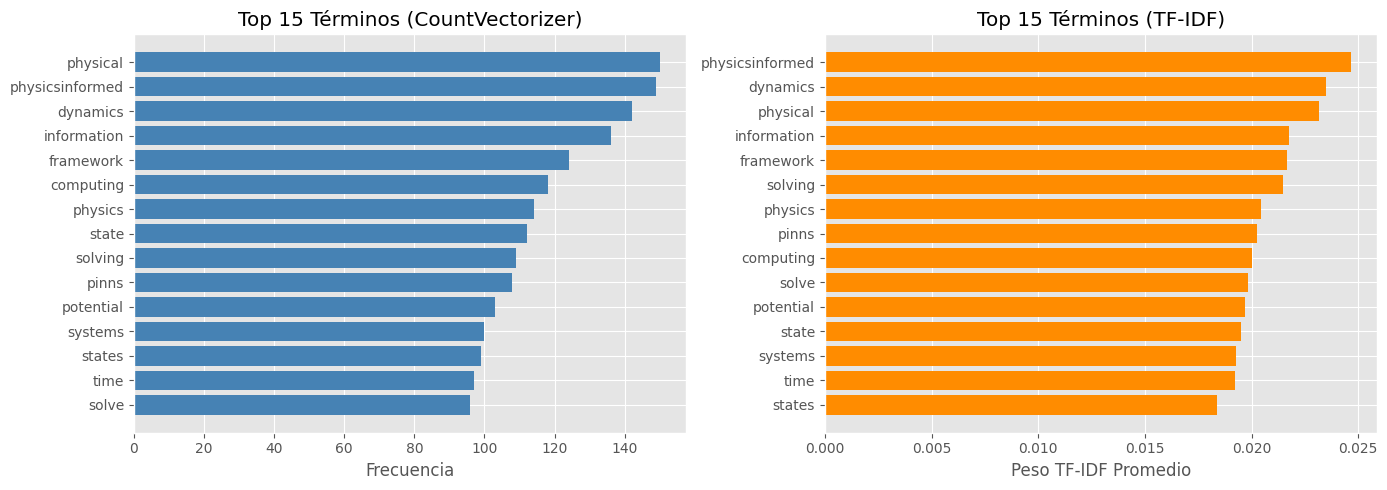

In [9]:
# Visualización de frecuencia de términos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frecuencias del CountVectorizer
word_counts = np.array(X_count.sum(axis=0)).flatten()
top_count_idx = word_counts.argsort()[-15:][::-1]

axes[0].barh(
    [count_vectorizer.get_feature_names_out()[i] for i in top_count_idx],
    [word_counts[i] for i in top_count_idx],
    color='steelblue'
)
axes[0].set_xlabel('Frecuencia')
axes[0].set_title('Top 15 Términos (CountVectorizer)')
axes[0].invert_yaxis()

# Pesos TF-IDF
axes[1].barh(
    [feature_names[i] for i in top_indices[:15]],
    [tfidf_scores[i] for i in top_indices[:15]],
    color='darkorange'
)
axes[1].set_xlabel('Peso TF-IDF Promedio')
axes[1].set_title('Top 15 Términos (TF-IDF)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# 4. Clustering con K-Means

Aplicaremos K-Means para agrupar los papers por similitud temática. 
Usaremos el **método del codo** para determinar el número óptimo de clusters.

=== Reducción de Dimensionalidad con SVD ===
Dimensiones originales: 1499
Dimensiones reducidas: 50
Varianza explicada: 31.01%

Calculando métricas para diferentes valores de K...
K=2: SSE=100.55, Silhouette=0.0272
K=3: SSE=98.21, Silhouette=0.0293
K=4: SSE=96.52, Silhouette=0.0273
K=5: SSE=94.89, Silhouette=0.0337
K=6: SSE=92.95, Silhouette=0.0392
K=4: SSE=96.52, Silhouette=0.0273
K=5: SSE=94.89, Silhouette=0.0337
K=6: SSE=92.95, Silhouette=0.0392
K=7: SSE=90.86, Silhouette=0.0368
K=8: SSE=89.58, Silhouette=0.0456
K=7: SSE=90.86, Silhouette=0.0368
K=8: SSE=89.58, Silhouette=0.0456
K=9: SSE=88.06, Silhouette=0.0480
K=10: SSE=86.71, Silhouette=0.0454
K=9: SSE=88.06, Silhouette=0.0480
K=10: SSE=86.71, Silhouette=0.0454


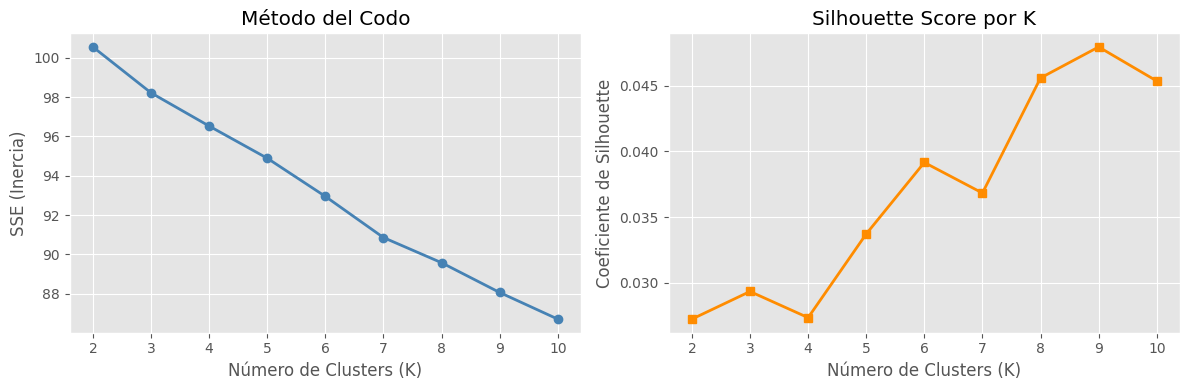


 Mejor K según Silhouette Score: 9
   Silhouette Score: 0.0480


In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD

# --- NUEVO: Reducción de dimensionalidad con SVD (LSA) ---
# Esto reduce el ruido y mejora el clustering
n_components = 50  # Reducir a 50 dimensiones
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

print(f"=== Reducción de Dimensionalidad con SVD ===")
print(f"Dimensiones originales: {X_tfidf.shape[1]}")
print(f"Dimensiones reducidas: {X_svd.shape[1]}")
print(f"Varianza explicada: {svd.explained_variance_ratio_.sum()*100:.2f}%")

# Usaremos la matriz reducida para el clustering
X = X_svd

# --- Método del Codo ---
SSE = []
silhouette_scores = []
K_range = range(2, 11)

print("\nCalculando métricas para diferentes valores de K...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X)
    SSE.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))
    print(f"K={k}: SSE={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

# Visualizar métricas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Método del Codo
axes[0].plot(K_range, SSE, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('SSE (Inercia)')
axes[0].set_title('Método del Codo')
axes[0].set_xticks(list(K_range))

# Coeficiente de Silhouette
axes[1].plot(K_range, silhouette_scores, marker='s', color='darkorange', linewidth=2)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Coeficiente de Silhouette')
axes[1].set_title('Silhouette Score por K')
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.show()

# Identificar el mejor K por Silhouette
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\n Mejor K según Silhouette Score: {best_k}")
print(f"   Silhouette Score: {max(silhouette_scores):.4f}")

In [22]:
# Entrenar modelo final con K óptimo (usaremos K=5 como balance entre interpretabilidad y granularidad)
# Puedes ajustar este valor según los resultados del método del codo
K_FINAL = 9

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20, max_iter=500)
df['cluster'] = kmeans_final.fit_predict(X)

print(f"Modelo K-Means entrenado con K={K_FINAL}")
print(f"\nDistribución de papers por cluster:")
print(df['cluster'].value_counts().sort_index())

Modelo K-Means entrenado con K=9

Distribución de papers por cluster:
cluster
0     9
1    79
2    25
3    30
4    53
5    27
6    52
7    17
8    59
Name: count, dtype: int64


# 5. Visualización 2D de los Clusters

Usaremos PCA (Análisis de Componentes Principales) para reducir la dimensionalidad y visualizar los clusters en 2D.

Varianza explicada por PCA (2D): 7.61%


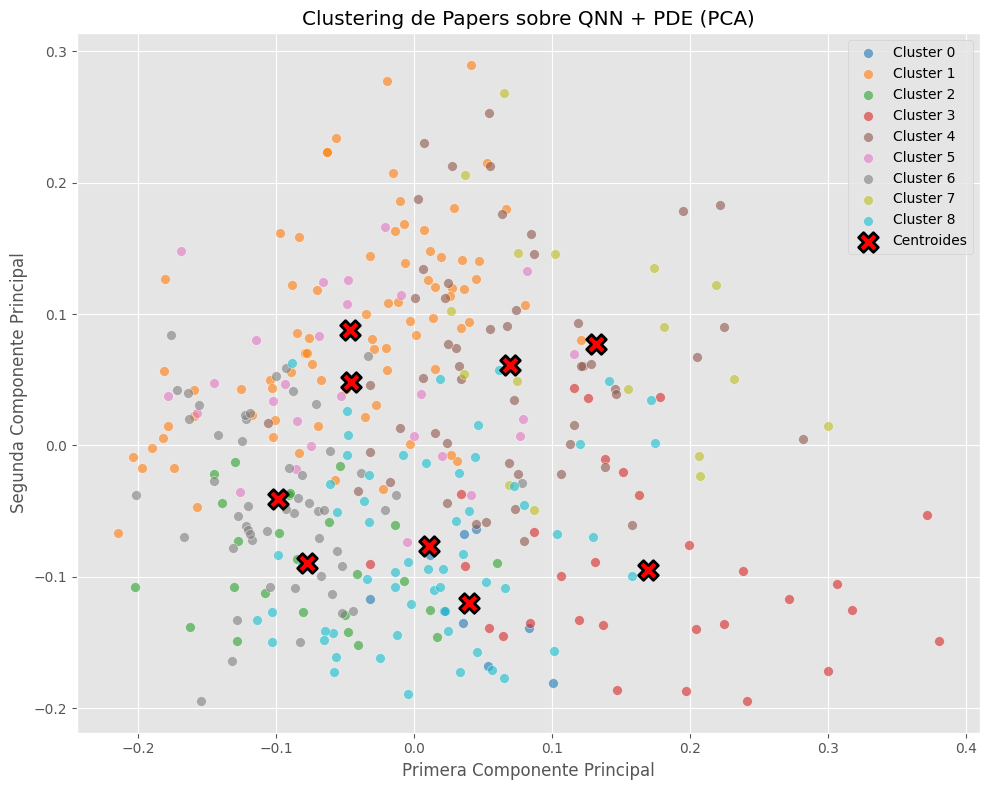

In [23]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# --- Reducción con PCA (sobre datos ya reducidos con SVD) ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)  # X ya es X_svd

# Transformar centroides a 2D
centroids_pca = pca.transform(kmeans_final.cluster_centers_)

print(f"Varianza explicada por PCA (2D): {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Visualización con PCA
fig, ax = plt.subplots(figsize=(10, 8))

# Colores para los clusters
colors = plt.cm.tab10(np.linspace(0, 1, K_FINAL))

for i in range(K_FINAL):
    mask = df['cluster'] == i
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[colors[i]], label=f'Cluster {i}',
        alpha=0.6, s=50, edgecolors='white', linewidth=0.5
    )

# Centroides
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c='red', marker='X', s=200, edgecolors='black',
    linewidth=2, label='Centroides'
)

ax.set_xlabel('Primera Componente Principal')
ax.set_ylabel('Segunda Componente Principal')
ax.set_title('Clustering de Papers sobre QNN + PDE (PCA)')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

Calculando t-SNE (puede tomar unos segundos)...


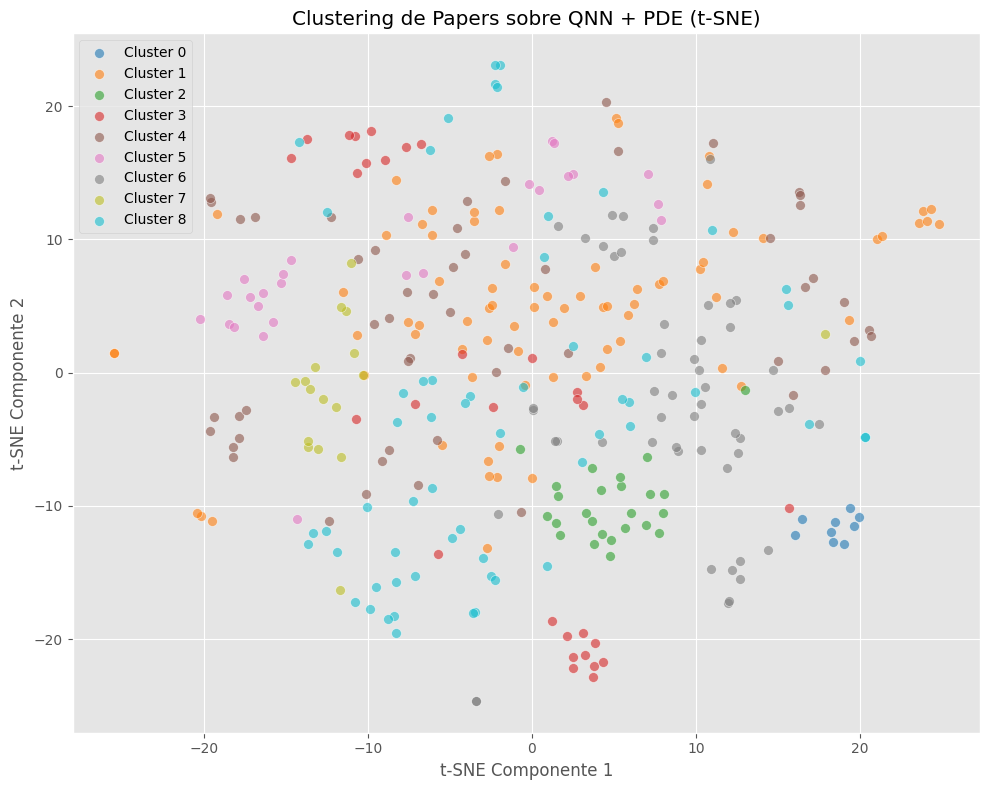

In [24]:
# --- Visualización alternativa con t-SNE (mejor para visualización) ---
print("Calculando t-SNE (puede tomar unos segundos)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X)  # X ya es X_svd (reducido)

fig, ax = plt.subplots(figsize=(10, 8))

for i in range(K_FINAL):
    mask = df['cluster'] == i
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=[colors[i]], label=f'Cluster {i}',
        alpha=0.6, s=50, edgecolors='white', linewidth=0.5
    )

ax.set_xlabel('t-SNE Componente 1')
ax.set_ylabel('t-SNE Componente 2')
ax.set_title('Clustering de Papers sobre QNN + PDE (t-SNE)')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# 6. Interpretación de los Clusters

Analizaremos los términos más representativos de cada cluster para entender qué subtemas agrupa cada uno.

In [25]:
def get_top_terms_per_cluster(tfidf_matrix, labels, vectorizer, n_terms=15):
    """
    Obtiene los términos más representativos de cada cluster
    basándose en los pesos TF-IDF promedio.
    """
    feature_names = vectorizer.get_feature_names_out()
    cluster_terms = {}
    
    for cluster_id in range(labels.max() + 1):
        # Obtener documentos del cluster
        cluster_mask = labels == cluster_id
        cluster_docs = tfidf_matrix[cluster_mask]
        
        # Calcular TF-IDF promedio por término
        mean_tfidf = np.array(cluster_docs.mean(axis=0)).flatten()
        
        # Obtener top términos
        top_indices = mean_tfidf.argsort()[-n_terms:][::-1]
        top_terms = [(feature_names[i], mean_tfidf[i]) for i in top_indices]
        
        cluster_terms[cluster_id] = top_terms
    
    return cluster_terms

# Obtener términos por cluster
cluster_terms = get_top_terms_per_cluster(X_tfidf, df['cluster'].values, tfidf_vectorizer)

# Mostrar resultados
print("=" * 80)
print("TÉRMINOS MÁS REPRESENTATIVOS POR CLUSTER")
print("=" * 80)

for cluster_id, terms in cluster_terms.items():
    print(f"\n{'='*40}")
    print(f"CLUSTER {cluster_id} ({(df['cluster'] == cluster_id).sum()} papers)")
    print(f"{'='*40}")
    for i, (term, score) in enumerate(terms, 1):
        print(f"  {i:2d}. {term:<25} (TF-IDF: {score:.4f})")

TÉRMINOS MÁS REPRESENTATIVOS POR CLUSTER

CLUSTER 0 (9 papers)
   1. cosmological              (TF-IDF: 0.1627)
   2. hubble                    (TF-IDF: 0.1191)
   3. dark                      (TF-IDF: 0.1111)
   4. dark energy               (TF-IDF: 0.1007)
   5. cosmic                    (TF-IDF: 0.0871)
   6. baryon                    (TF-IDF: 0.0831)
   7. tension                   (TF-IDF: 0.0815)
   8. observational             (TF-IDF: 0.0804)
   9. constant                  (TF-IDF: 0.0801)
  10. acoustic oscillations     (TF-IDF: 0.0684)
  11. ia                        (TF-IDF: 0.0684)
  12. acoustic                  (TF-IDF: 0.0684)
  13. baryon acoustic           (TF-IDF: 0.0684)
  14. background                (TF-IDF: 0.0639)
  15. oscillations              (TF-IDF: 0.0630)

CLUSTER 1 (79 papers)
   1. computing                 (TF-IDF: 0.0385)
   2. hybrid                    (TF-IDF: 0.0348)
   3. dynamics                  (TF-IDF: 0.0330)
   4. physicsinformed           

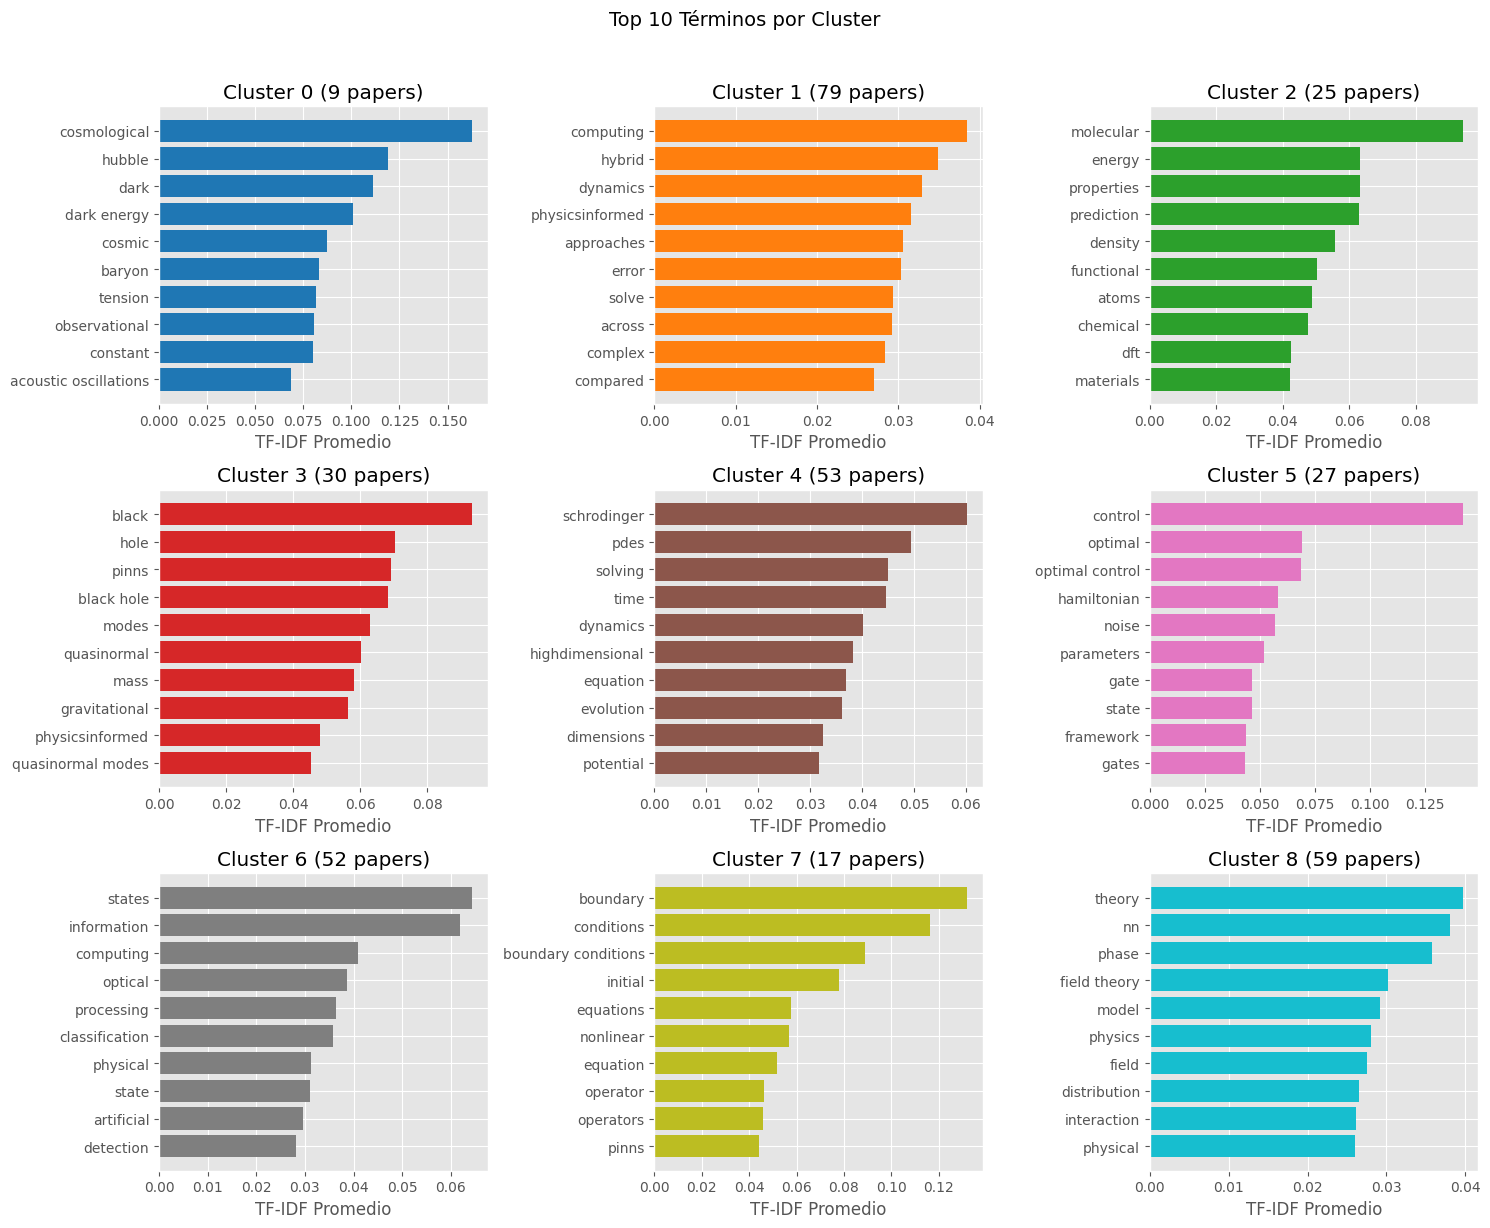

In [26]:
# Visualización de términos por cluster
n_rows = 3
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.flatten()

for cluster_id in range(K_FINAL):
    ax = axes[cluster_id]
    terms = cluster_terms[cluster_id][:10]  # Top 10
    
    terms_names = [t[0] for t in terms]
    terms_scores = [t[1] for t in terms]
    
    ax.barh(terms_names[::-1], terms_scores[::-1], color=colors[cluster_id])
    ax.set_xlabel('TF-IDF Promedio')
    ax.set_title(f'Cluster {cluster_id} ({(df["cluster"] == cluster_id).sum()} papers)')

# Ocultar subplots extra si K < 9
for i in range(K_FINAL, n_rows * n_cols):
    axes[i].axis('off')

plt.suptitle('Top 10 Términos por Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [27]:
# Mostrar títulos de papers representativos por cluster
print("=" * 80)
print("PAPERS REPRESENTATIVOS POR CLUSTER")
print("=" * 80)

for cluster_id in range(K_FINAL):
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*50}")
    
    cluster_papers = df[df['cluster'] == cluster_id]
    
    # Mostrar 3-5 papers de ejemplo
    for i, (_, row) in enumerate(cluster_papers.head(5).iterrows()):
        print(f"\n{i+1}. {row['title'][:100]}...")
        print(f"   Categoría: {row['category']}")

PAPERS REPRESENTATIVOS POR CLUSTER

CLUSTER 0

1. Some New Types of Well-Behaved Polynomial Redshift Parametrization of Dark Energy Equation of State...
   Categoría: gr-qc

2. A Systematic Literature Review of Machine Learning Techniques for Observational Constraints in Cosmo...
   Categoría: astro-ph.CO

3. Cosmology-informed neural networks to solve the background dynamics of the Universe...
   Categoría: astro-ph.CO

4. Inferring Cosmological Parameters with Evidential Physics-Informed Neural Networks...
   Categoría: astro-ph.CO

5. Towards a Machine Learning Solution for Hubble Tension: Physics-Informed Neural Network (PINN) Analy...
   Categoría: astro-ph.CO

CLUSTER 1

1. Quantum-Classical Physics-Informed Neural Networks for Solving Reservoir Seepage Equations...
   Categoría: cs.LG

2. Quantum Orthogonal Separable Physics-Informed Neural Networks...
   Categoría: quant-ph

3. Quantum Random Feature Method for Solving Partial Differential Equations...
   Categoría: quant-ph

4


DISTRIBUCIÓN DE CATEGORÍAS POR CLUSTER
category  astro-ph.CO  astro-ph.HE  cond-mat.dis-nn  cond-mat.mes-hall  \
cluster                                                                  
0                   7            0                0                  0   
1                   1            0                0                  0   
2                   0            0                0                  0   
3                   0            2                0                  0   
4                   0            0                2                  0   
5                   0            0                0                  1   
6                   0            0                3                  1   
7                   0            0                0                  0   
8                   0            2                0                  0   

category  cond-mat.mtrl-sci  cond-mat.quant-gas  cond-mat.soft  \
cluster                                                          
0            

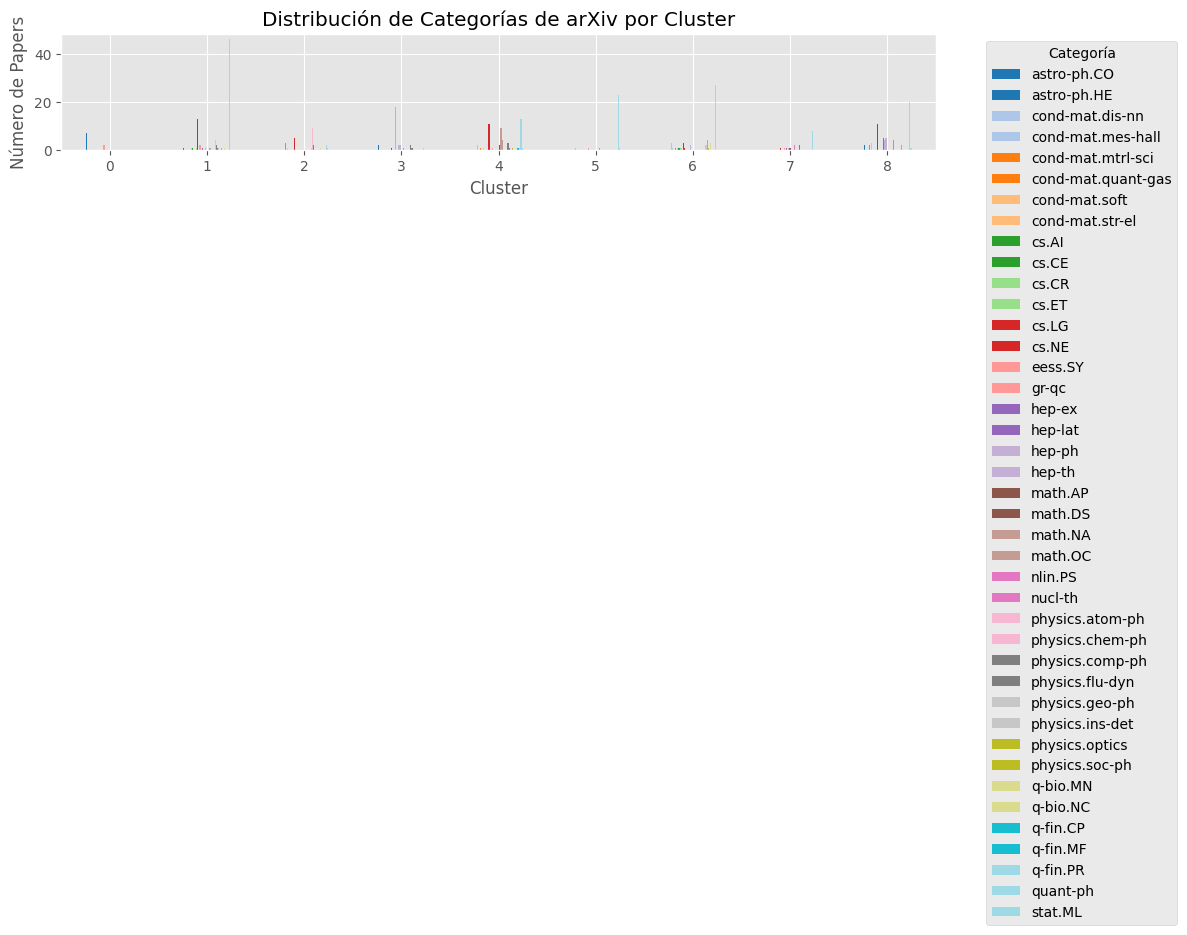

In [28]:
# Análisis de distribución por categoría y cluster
print("\n" + "=" * 80)
print("DISTRIBUCIÓN DE CATEGORÍAS POR CLUSTER")
print("=" * 80)

cluster_category = pd.crosstab(df['cluster'], df['category'])
print(cluster_category)

# Visualización
fig, ax = plt.subplots(figsize=(12, 6))
cluster_category.plot(kind='bar', ax=ax, colormap='tab20')
ax.set_xlabel('Cluster')
ax.set_ylabel('Número de Papers')
ax.set_title('Distribución de Categorías de arXiv por Cluster')
ax.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Algoritmos de Clustering Adicionales

Probemos otros algoritmos de clustering para comparar resultados.

In [29]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# --- Clustering Jerárquico Aglomerativo ---
hierarchical = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
labels_hierarchical = hierarchical.fit_predict(X)  # X ya es X_svd

# --- DBSCAN ---
# Ajustamos eps para datos reducidos con SVD
dbscan = DBSCAN(eps=1.5, min_samples=5)  # Parámetros ajustados para SVD
labels_dbscan = dbscan.fit_predict(X)

# Comparar resultados
print("=== COMPARACIÓN DE ALGORITMOS DE CLUSTERING ===\n")

# Silhouette Score para cada método
print("Silhouette Score:")
print(f"  K-Means:              {silhouette_score(X, df['cluster']):.4f}")
print(f"  Jerárquico (Ward):    {silhouette_score(X, labels_hierarchical):.4f}")

# Para DBSCAN, excluir puntos de ruido (-1)
n_clusters_dbscan = len(set(labels_dbscan) - {-1})
if n_clusters_dbscan > 1:
    mask_no_noise = labels_dbscan != -1
    if mask_no_noise.sum() > n_clusters_dbscan:
        print(f"  DBSCAN:               {silhouette_score(X[mask_no_noise], labels_dbscan[mask_no_noise]):.4f}")
else:
    print(f"  DBSCAN:               N/A (detectó {n_clusters_dbscan} clusters, {(labels_dbscan == -1).sum()} puntos de ruido)")

print(f"\nNúmero de clusters encontrados:")
print(f"  K-Means:              {K_FINAL}")
print(f"  Jerárquico:           {K_FINAL}")
print(f"  DBSCAN:               {n_clusters_dbscan}")

=== COMPARACIÓN DE ALGORITMOS DE CLUSTERING ===

Silhouette Score:
  K-Means:              0.0436
  Jerárquico (Ward):    0.0472
  DBSCAN:               N/A (detectó 1 clusters, 0 puntos de ruido)

Número de clusters encontrados:
  K-Means:              9
  Jerárquico:           9
  DBSCAN:               1


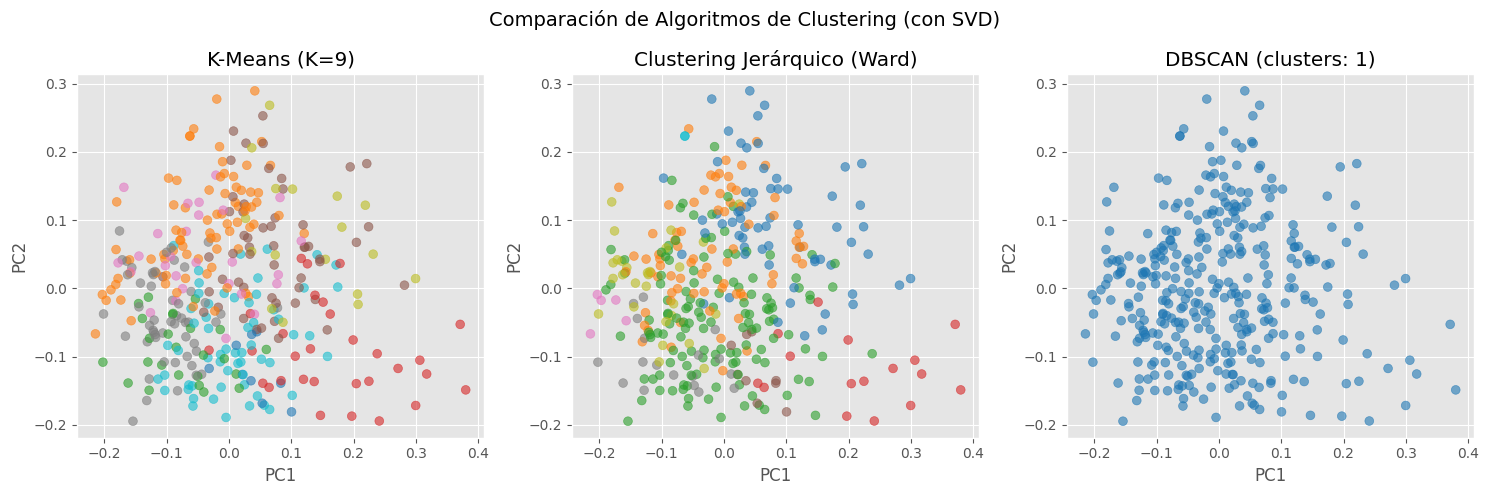

In [30]:
# Visualización comparativa de clustering
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# K-Means
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='tab10', alpha=0.6, s=40)
axes[0].set_title(f'K-Means (K={K_FINAL})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Jerárquico
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hierarchical, cmap='tab10', alpha=0.6, s=40)
axes[1].set_title(f'Clustering Jerárquico (Ward)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# DBSCAN
scatter = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbscan, cmap='tab10', alpha=0.6, s=40)
axes[2].set_title(f'DBSCAN (clusters: {len(set(labels_dbscan) - {-1})})')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.suptitle('Comparación de Algoritmos de Clustering (con SVD)', fontsize=14)
plt.tight_layout()
plt.show()

# 8. Conclusiones: ¿Qué Subtema es Más Prometedor para la Tesis?

## Resumen del Análisis

Basándonos en el análisis de clustering de papers sobre **Quantum Neural Networks + Partial Differential Equations**, podemos identificar los siguientes subtemas principales:

In [31]:
# Generar resumen de interpretación de clusters
print("=" * 80)
print("INTERPRETACIÓN DE CLUSTERS Y SUBTEMAS IDENTIFICADOS")
print("=" * 80)

# Crear nombres interpretativos basados en los términos principales
cluster_interpretations = []

for cluster_id in range(K_FINAL):
    terms = cluster_terms[cluster_id][:8]
    top_keywords = [t[0] for t in terms]
    n_papers = (df['cluster'] == cluster_id).sum()
    
    print(f"\n CLUSTER {cluster_id} ({n_papers} papers)")
    print(f"   Palabras clave: {', '.join(top_keywords)}")
    
    cluster_interpretations.append({
        'cluster': cluster_id,
        'n_papers': n_papers,
        'keywords': top_keywords
    })

INTERPRETACIÓN DE CLUSTERS Y SUBTEMAS IDENTIFICADOS

 CLUSTER 0 (9 papers)
   Palabras clave: cosmological, hubble, dark, dark energy, cosmic, baryon, tension, observational

 CLUSTER 1 (79 papers)
   Palabras clave: computing, hybrid, dynamics, physicsinformed, approaches, error, solve, across

 CLUSTER 2 (25 papers)
   Palabras clave: molecular, energy, properties, prediction, density, functional, atoms, chemical

 CLUSTER 3 (30 papers)
   Palabras clave: black, hole, pinns, black hole, modes, quasinormal, mass, gravitational

 CLUSTER 4 (53 papers)
   Palabras clave: schrodinger, pdes, solving, time, dynamics, highdimensional, equation, evolution

 CLUSTER 5 (27 papers)
   Palabras clave: control, optimal, optimal control, hamiltonian, noise, parameters, gate, state

 CLUSTER 6 (52 papers)
   Palabras clave: states, information, computing, optical, processing, classification, physical, state

 CLUSTER 7 (17 papers)
   Palabras clave: boundary, conditions, boundary conditions, initia